In [1]:
import sys
sys.path.append('../../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.grid'        : False,
    'font.size'        : 11,
})

from src.io.save_artifacts import load_parquet, save_csv, create_dirs
from src.validation.check_categorical_profile import check_categorical_profile

df = load_parquet('../../data/processed/lending_club_target.parquet')
print(df.shape)

📂 Parquet okunuyor: ../../data/processed/lending_club_target.parquet
✅ Okundu!
   Satır : 1,345,350
   Sütun : 153
   Süre  : 0.6 saniye
(1345350, 153)


In [2]:
profil = check_categorical_profile(df, hedef_kolon='target')

create_dirs('../../artifacts')
save_csv(profil, '../../artifacts/categorical_profile.csv')

profil

── Kategorik Kolon Profili ───────────────────
   Toplam kategorik     : 38
   Düşük kardinalite   : 15  (≤5 benzersiz)
   Orta kardinalite    : 9   (6-50)
   Yüksek kardinalite  : 14  (>50)
📁 Klasör hazır: ../../artifacts
💾 CSV kaydediliyor: ../../artifacts/categorical_profile.csv
✅ Kaydedildi!
   Boyut : 0.0 MB
   Süre  : 0.0 saniye


,kolon,n_unique,kardinalite,eksik_oran,en_sik_deger,en_sik_oran
0,pk,1345350,yüksek,0.00,68407277,0.0
1,url,1345350,yüksek,0.00,https://lendingclub.com/browse/loanDetail.acti...,0.0
2,emp_title,378358,yüksek,6.38,Teacher,1.7
3,desc,122004,yüksek,90.82,,0.2
4,title,61681,yüksek,1.24,Debt consolidation,49.7
5,zip_code,943,yüksek,0.00,945xx,1.1
6,earliest_cr_line,739,yüksek,0.00,Aug-2001,0.7
7,sec_app_earliest_cr_line,570,yüksek,98.61,Aug-2006,1.1
8,last_credit_pull_d,140,yüksek,0.00,Mar-2019,35.0
9,issue_d,139,yüksek,0.00,Mar-2016,3.6


In [3]:
ONEMLI = ['grade', 'sub_grade', 'home_ownership',
          'verification_status', 'purpose',
          'emp_length', 'term', 'initial_list_status']

mevcut = [c for c in ONEMLI if c in df.columns]

print("── Önemli Kategorik Kolonlar ────────────────")
for k in mevcut:
    print(f"\n{k} ({df[k].nunique()} benzersiz):")
    print(df[k].value_counts().to_string())

── Önemli Kategorik Kolonlar ────────────────

grade (7 benzersiz):
grade
B    392748
C    381694
A    235095
D    200966
E     93656
F     32059
G      9132

sub_grade (35 benzersiz):
sub_grade
C1    85496
B4    83200
B5    82541
B3    81828
C2    79215
C3    75000
C4    74422
B2    74025
B1    71154
C5    67561
A5    64005
A4    52236
D1    51323
D2    44851
A1    43679
D3    39322
A3    37997
A2    37178
D4    35568
D5    29902
E1    23749
E2    21378
E3    18387
E4    15723
E5    14419
F1     9970
F2     7198
F3     6088
F4     4859
F5     3944
G1     2997
G2     2131
G3     1614
G4     1280
G5     1110

home_ownership (6 benzersiz):
home_ownership
MORTGAGE    665596
RENT        534436
OWN         144840
ANY            286
OTHER          144
NONE            48

verification_status (3 benzersiz):
verification_status
Source Verified    521289
Verified           418352
Not Verified       405709

purpose (14 benzersiz):
purpose
debt_consolidation    780342
credit_card           295285


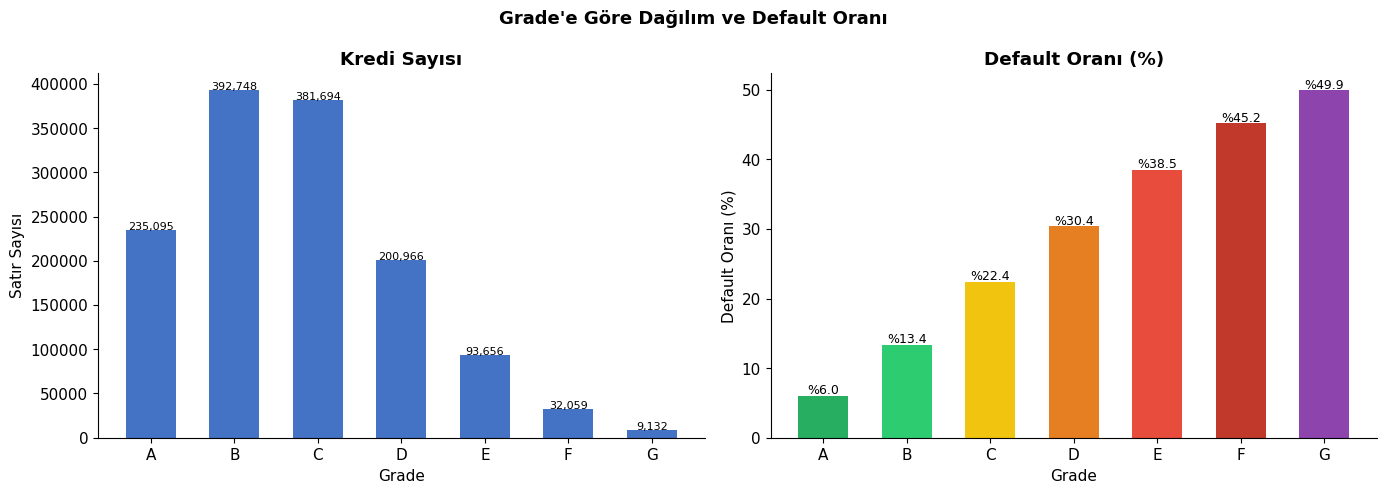

✅ 04_grade_default.png kaydedildi


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Grade'e Göre Dağılım ve Default Oranı",
             fontsize=13, fontweight='bold')

# Sol — kredi sayısı
grade_cnt = df['grade'].value_counts().sort_index()
axes[0].bar(grade_cnt.index, grade_cnt.values,
            color='#4472C4', edgecolor='none', width=0.6)
axes[0].set_title('Kredi Sayısı', fontweight='bold')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Satır Sayısı')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for i, (g, v) in enumerate(grade_cnt.items()):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=8)

# Sağ — default oranı
grade_def = df.groupby('grade')['target'].mean().sort_index() * 100
renkler = ['#27AE60','#2ECC71','#F1C40F',
           '#E67E22','#E74C3C','#C0392B','#8E44AD']
bars = axes[1].bar(grade_def.index, grade_def.values,
                   color=renkler[:len(grade_def)],
                   edgecolor='none', width=0.6)
axes[1].set_title('Default Oranı (%)', fontweight='bold')
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Default Oranı (%)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for bar, v in zip(bars, grade_def.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 v + 0.3, f'%{v:.1f}',
                 ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../../reports/eda_plots/04_grade_default.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ 04_grade_default.png kaydedildi')

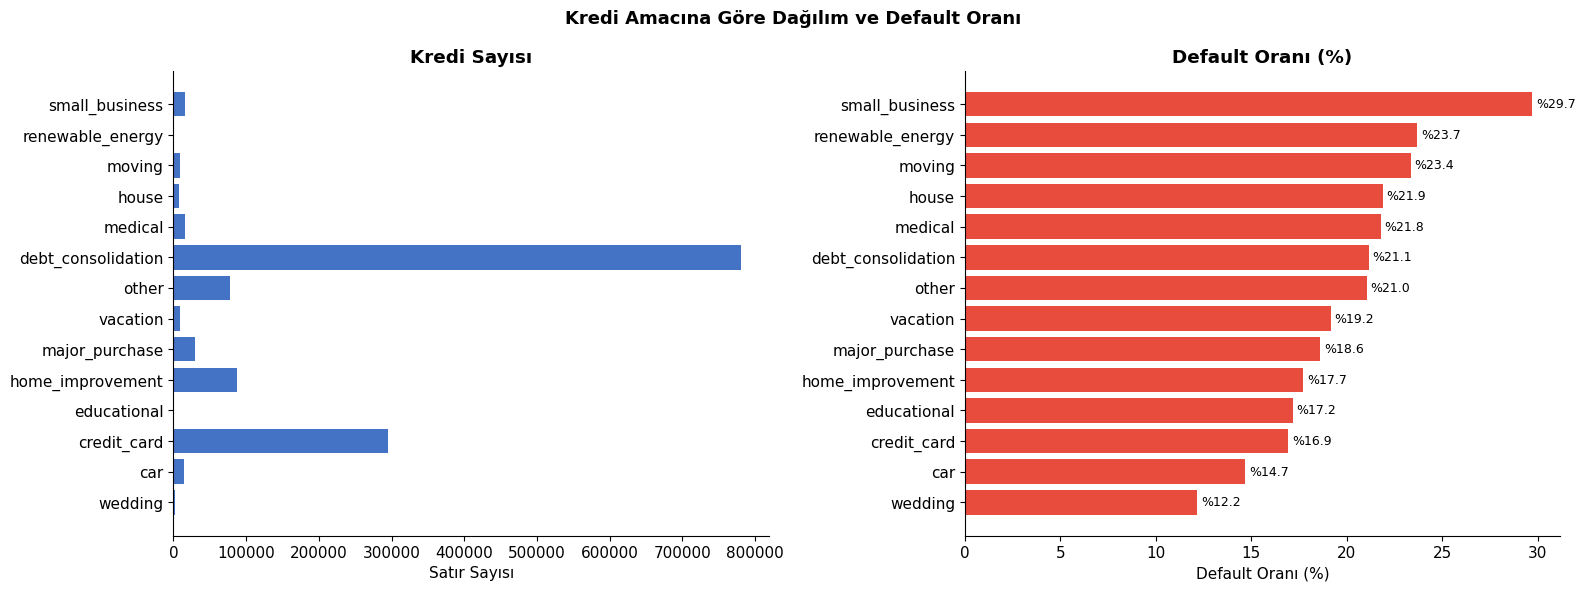

✅ 04_purpose_default.png kaydedildi


In [5]:
purpose_def = df.groupby('purpose').agg(
    sayi         = ('target', 'count'),
    default_orani = ('target', 'mean')
).reset_index()
purpose_def['default_orani'] *= 100
purpose_def = purpose_def.sort_values('default_orani', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Kredi Amacına Göre Dağılım ve Default Oranı",
             fontsize=13, fontweight='bold')

# Sol — kredi sayısı
axes[0].barh(purpose_def['purpose'], purpose_def['sayi'],
             color='#4472C4', edgecolor='none')
axes[0].set_title('Kredi Sayısı', fontweight='bold')
axes[0].set_xlabel('Satır Sayısı')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Sağ — default oranı
axes[1].barh(purpose_def['purpose'], purpose_def['default_orani'],
             color='#E74C3C', edgecolor='none')
axes[1].set_title('Default Oranı (%)', fontweight='bold')
axes[1].set_xlabel('Default Oranı (%)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for i, v in enumerate(purpose_def['default_orani']):
    axes[1].text(v + 0.2, i, f'%{v:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../../reports/eda_plots/04_purpose_default.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ 04_purpose_default.png kaydedildi')

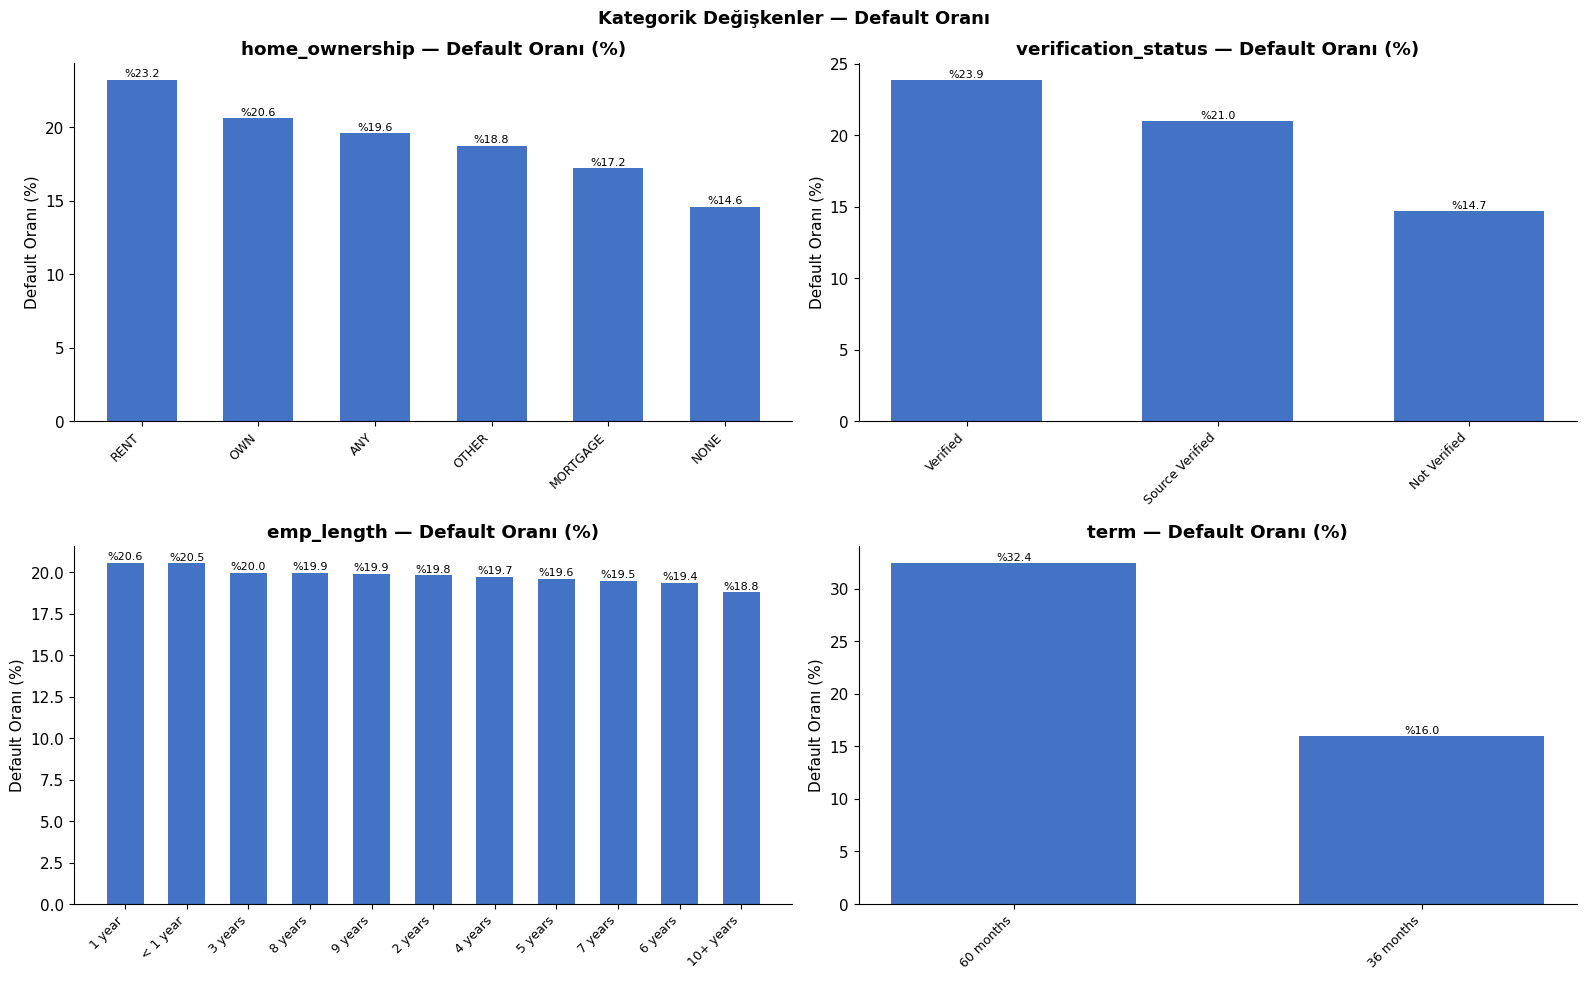

✅ 04_kategorik_default.png kaydedildi


In [6]:
GOSTER = ['home_ownership', 'verification_status',
          'emp_length', 'term']
mevcut_goster = [c for c in GOSTER if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Kategorik Değişkenler — Default Oranı',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, kolon in enumerate(mevcut_goster):
    ax = axes[i]

    kat_def = df.groupby(kolon)['target'].mean() * 100
    kat_def = kat_def.sort_values(ascending=False)

    # Sadece anlamlı kategoriler
    if len(kat_def) > 15:
        kat_def = kat_def.head(15)

    bars = ax.bar(range(len(kat_def)), kat_def.values,
                  color='#4472C4', edgecolor='none', width=0.6)
    ax.set_xticks(range(len(kat_def)))
    ax.set_xticklabels(kat_def.index, rotation=45,
                       ha='right', fontsize=9)
    ax.set_title(f'{kolon} — Default Oranı (%)',
                 fontweight='bold')
    ax.set_ylabel('Default Oranı (%)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bar, v in zip(bars, kat_def.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                v + 0.2, f'%{v:.1f}',
                ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../../reports/eda_plots/04_kategorik_default.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ 04_kategorik_default.png kaydedildi')

In [7]:
# Dokümandan: purpose 47 değer → 8 grup
# grade A-G → 3 grup
# Bu kararlar 03_ozellik_muhendisligi adımında uygulanacak

purpose_unique = df['purpose'].value_counts()
print("── Purpose Değerleri ────────────────────────")
print(f"   Toplam benzersiz: {df['purpose'].nunique()}")
print(purpose_unique.to_string())

print("\n── Grade Değerleri ──────────────────────────")
print(df['grade'].value_counts().sort_index().to_string())

print("\n── Encoding Kararları ───────────────────────")
print("   grade        → Ordinal (A=1, B=2, ... G=7)")
print("   sub_grade    → Ordinal (A1=1 ... G5=35)")
print("   term         → Binary  (36=0, 60=1)")
print("   emp_length   → Ordinal ('< 1 year'=0 ... '10+ years'=10)")
print("   home_ownership → One-hot")
print("   verification_status → One-hot")
print("   purpose      → Gruplandır → One-hot")
print("   initial_list_status → Binary")

── Purpose Değerleri ────────────────────────
   Toplam benzersiz: 14
purpose
debt_consolidation    780342
credit_card           295285
home_improvement       87507
other                  77877
major_purchase         29427
medical                15556
small_business         15416
car                    14588
moving                  9480
vacation                9065
house                   7254
wedding                 2294
renewable_energy         933
educational              326

── Grade Değerleri ──────────────────────────
grade
A    235095
B    392748
C    381694
D    200966
E     93656
F     32059
G      9132

── Encoding Kararları ───────────────────────
   grade        → Ordinal (A=1, B=2, ... G=7)
   sub_grade    → Ordinal (A1=1 ... G5=35)
   term         → Binary  (36=0, 60=1)
   emp_length   → Ordinal ('< 1 year'=0 ... '10+ years'=10)
   home_ownership → One-hot
   verification_status → One-hot
   purpose      → Gruplandır → One-hot
   initial_list_status → Binary


In [8]:
import json

encoding_kararlari = {
    "ordinal": {
        "grade": {"A":1,"B":2,"C":3,"D":4,"E":5,"F":6,"G":7},
        "term" : {"36 months":0, "60 months":1},
        "emp_length": {
            "< 1 year":0, "1 year":1, "2 years":2,
            "3 years":3,  "4 years":4, "5 years":5,
            "6 years":6,  "7 years":7, "8 years":8,
            "9 years":9,  "10+ years":10
        },
        "initial_list_status": {"w":0, "f":1}
    },
    "one_hot": [
        "home_ownership",
        "verification_status"
    ],
    "grupla_sonra_one_hot": {
        "purpose": {
            "borc"   : ["debt_consolidation", "credit_card"],
            "ev"     : ["home_improvement", "house", "moving"],
            "alisveris": ["major_purchase", "car",
                          "vacation", "wedding"],
            "is"     : ["small_business"],
            "saglik" : ["medical"],
            "egitim" : ["educational"],
            "diger"  : ["other", "renewable_energy"]
        }
    },
    "dusur": ["sub_grade"]
}

with open('../../artifacts/encoding_decisions.json', 'w',
          encoding='utf-8') as f:
    json.dump(encoding_kararlari, f, indent=2, ensure_ascii=False)

print("✅ artifacts/encoding_decisions.json kaydedildi")

✅ artifacts/encoding_decisions.json kaydedildi


In [9]:
print("=" * 52)
print("  04_kategorik_degisken_analizi TAMAMLANDI")
print("=" * 52)
print(f"  Kategorik kolon sayısı : {len(profil)}")
print(f"  Düşük kardinalite      : "
      f"{(profil['kardinalite']=='düşük').sum()}")
print(f"  Orta kardinalite       : "
      f"{(profil['kardinalite']=='orta').sum()}")
print(f"  Yüksek kardinalite     : "
      f"{(profil['kardinalite']=='yüksek').sum()}")
print()
print("  Kaydedilen dosyalar:")
print("  📊 artifacts/categorical_profile.csv")
print("  📊 artifacts/encoding_decisions.json")
print("  🖼  reports/eda_plots/04_grade_default.png")
print("  🖼  reports/eda_plots/04_purpose_default.png")
print("  🖼  reports/eda_plots/04_kategorik_default.png")
print("=" * 52)
print("→ Sıradaki: 05_eksik_deger_analizi.ipynb")

  04_kategorik_degisken_analizi TAMAMLANDI
  Kategorik kolon sayısı : 38
  Düşük kardinalite      : 15
  Orta kardinalite       : 9
  Yüksek kardinalite     : 14

  Kaydedilen dosyalar:
  📊 artifacts/categorical_profile.csv
  📊 artifacts/encoding_decisions.json
  🖼  reports/eda_plots/04_grade_default.png
  🖼  reports/eda_plots/04_purpose_default.png
  🖼  reports/eda_plots/04_kategorik_default.png
→ Sıradaki: 05_eksik_deger_analizi.ipynb
